In [ ]:
import sys
!{sys.executable} -m pip install matplotlib seaborn plotly scikit-learn

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

In [10]:
df = pd.read_csv('data:/data.csv')
print(df.shape)
df.head(10)

(10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,15574012,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,15592531,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,15656148,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,15792365,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,15592389,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


**[önümde 12 kolon ve 10000 müşteri bulunduğunu fark ettim, bazı hesaplarda hiç para yok yani hesaplarında para tutmadıklarını anladım. hedef değişkenim churn hazır. ]**

In [12]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 1.0 MB


customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [ ]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


**ilk öncelikle bu tabloya baktığımda ortalama yaş kısmının 38 olduğunu fakat ortalama yaşın benim istediğim sonuçları vermediğini, çeyrek olarak nitelendirilen oranlara göre yorum yapmam gerektiğini anladım. müşterilerin çeyreği 32 yaşından küçük; yarısı 37 yaşından küçük; %75'i yani 3 çeyreklik kısmı ise 44 yaşından küçük. aynı şekilde bu hizmeti kullanmak için 18 yaşından büyük olmak gerektiğini de anladım. müşterilerin en az %50'si yani yarısı tek ürün kullanıyor. churn ortalamasına(mean) baktığım zaman ise 0.203700'lük oran müşterilerimizin yaklaşık %20'sinin kaçtığını gösteriyor. bu da verinin dengesizliğini gösteriyor ve model kurarken buna dikkat etmem gerekiyor.**

In [16]:
df.groupby('products_number')['churn'].mean()

products_number
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: churn, dtype: float64

In [17]:
df.groupby('products_number')['churn'].agg(['mean', 'count'])

,mean,count
products_number,,
1,0.277144,5084
2,0.075817,4590
3,0.827068,266
4,1.000000,60


In [ ]:
#kullanılan ürün sayısına göre churn oranı tablosu
stats = df.groupby('products_number')['churn'].agg(['mean', 'count'])

plt.figure(figsize=(8, 5))
bars = plt.bar(stats.index, stats['mean'], color='orange', edgecolor='black')

for bar, (mean, count) in zip(bars, zip(stats['mean'], stats['count'])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'%{mean*100:.1f}\n(n={count})',
             ha='center', va='bottom', fontsize=10)

plt.xlabel('Ürün sayısı')
plt.ylabel('Churn oranı')
plt.title('Kullanılan ürün sayısına göre churn oranı')
plt.xticks([1, 2, 3, 4])
plt.ylim(0, 1.15)  
plt.savefig('figures/churn_by_products.png', dpi=150, bbox_inches='tight')
plt.show()

**ilk izlenimim olarak beklentimi karşılayan ve karşılamayan bir tablo olduğunu söyleyebilirim. bir ürün kullanan insanların terk etme oranı %27.7 iken 2 ürün kullanan insanların terk etme oranının büyük bir düşüşle %7.6'ya düşmesi şaşırtan bir sonuç olmadı benim için. fakat 3 ürün ve 4 ürün kullanan müşterilere bakınca terk etme oranı tam olarak bir U çiziyor, hatta beklentimi direkt olarak reddederek 4 ürün kullanan müşteriler 3 ürün kullananlardan daha fazla terk ediyor gibi gözüküyor fakat 10.000 müşterilik bir veri setinde 60 tane 4 ürün kullanan müşteri olunca buradaki 4 ürün kullanan müşterileri hesaba katmamam gerektiğini düşünüyorum. sonuç olarak vardığım kanı ilk iki örneklemde beklediğim sonuçları yani ürün sayısı-sadıklık skalasına uyan bir sonuç alıyorum. ilk iki örneklem için churn ile ürün sayısının ters orantılı olduğunu anlıyorum.**

FileNotFoundError: [Errno 2] No such file or directory: 'figures/churn_by_active.png'

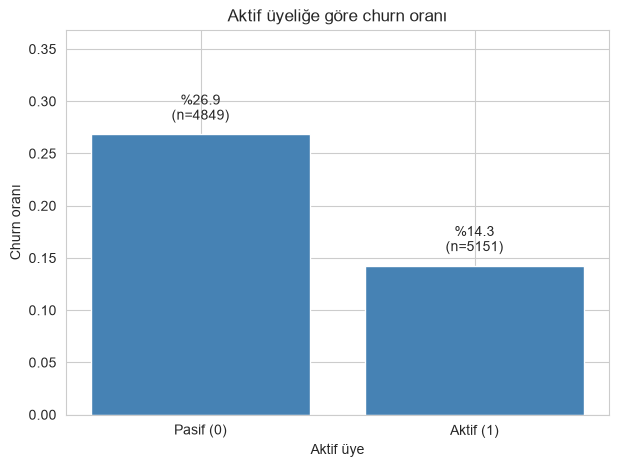

In [26]:
#aktif üyeliğe göre churn oranı tablosu
stats_active = df.groupby('active_member')['churn'].agg(['mean', 'count'])

plt.figure(figsize=(7, 5))
bars = plt.bar(stats_active.index, stats_active['mean'], color='steelblue', edgecolor='white')

for bar, (mean, count) in zip(bars, zip(stats_active['mean'], stats_active['count'])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'%{mean*100:.1f}\n(n={count})',
             ha='center', va='bottom', fontsize=10)

plt.xlabel('Aktif üye')
plt.ylabel('Churn oranı')
plt.title('Aktif üyeliğe göre churn oranı')
plt.xticks([0, 1], ['Pasif (0)', 'Aktif (1)'])
plt.ylim(0, max(stats_active['mean']) + 0.1)
plt.savefig('figures/churn_by_active.png', dpi=150, bbox_inches='tight')
plt.show()

**gördüğüm şey yaklaşık %27'lik pasif hesap ve %14'lük aktif hesap ve pasif olan hesapların aktif olanlara göre terk etme oranının daha yüksek olduğu. bu oran yaklaşık olarak 2 kat fark ediyor ve bu verilere güvenebileceğimi düşünüyorum çünkü 2 örneklem sahibiyim ve sayılar çok yüksek. buradan çıkardığım sonuç müşteriyi aktif tutmanın terk etme oranını azalttığı. dolayısıyla pasif müşterileri aktif hale getirmek banka için daha fazla elde tutulan müşteri demek olabilir.**

In [27]:
df['ltv_proxy'] = df['balance'] * df['tenure']
df.groupby('churn')['ltv_proxy'].agg(['mean', 'median', 'count'])

,mean,median,count
churn,,,
0,362462.70640,198339.34,7963
1,454434.16377,361705.23,2037


**çıktıya göre kaçan müşteriler kalanlardan daha değerli gözüküyor. kaçanların medyan ltv proxy değeri yaklaşık 361.000 iken kalanların 198.000, yani neredeyse 2 kat fark var. burada dikkatimi çeken şey sadece ortalamanın değil medyanın da aynı yönü göstermesi, bu da bu farkın birkaç aşırı zengin müşteriden değil tipik kaçan müşteriden kaynaklandığını gösteriyor. yani banka değersiz müşterilerini değil tam tersine değerli müşterilerini kaybediyor, bu da churnu ciddi bir maliyet sorununa çeviriyor. not olarak ltv proxy gerçek bir ltv değil, balance ile tenure çarpımından türettiğim kaba bir gösterge.**

FileNotFoundError: [Errno 2] No such file or directory: 'figures/ltv_by_churn.png'

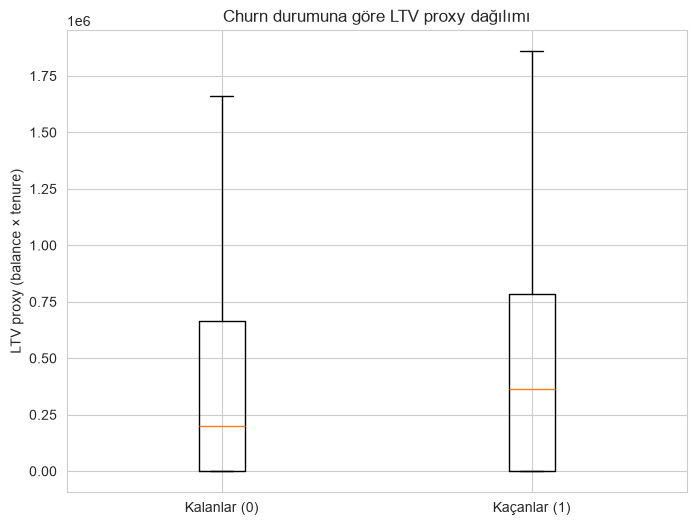

In [30]:
#LTV
plt.figure(figsize=(8, 6))

data_retained = df[df['churn'] == 0]['ltv_proxy']
data_churned = df[df['churn'] == 1]['ltv_proxy']

plt.boxplot([data_retained, data_churned],
            tick_labels=['Kalanlar (0)', 'Kaçanlar (1)'],
            showfliers=False)

plt.ylabel('LTV proxy (balance × tenure)')
plt.title('Churn durumuna göre LTV proxy dağılımı')
plt.savefig('figures/ltv_by_churn.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].hist(df['age'], bins=30, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Age')

axes[0, 1].hist(df['balance'], bins=30, color='seagreen', edgecolor='white')
axes[0, 1].set_title('Balance')

axes[0, 2].hist(df['estimated_salary'], bins=30, color='darkorange', edgecolor='white')
axes[0, 2].set_title('Estimated Salary')

axes[1, 0].hist(df['credit_score'], bins=30, color='mediumpurple', edgecolor='white')
axes[1, 0].set_title('Credit Score')

axes[1, 1].bar(df['tenure'].value_counts().index, df['tenure'].value_counts().values, color='tomato')
axes[1, 1].set_title('Tenure')

axes[1, 2].pie(df['churn'].value_counts(), labels=['Retained', 'Churned'],
               autopct='%1.1f%%', colors=['steelblue', 'tomato'])
axes[1, 2].set_title('Churn')

plt.tight_layout()
plt.savefig('figures/distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
numeric_cols = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary', 'churn']
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Korelasyon Matrisi')
plt.tight_layout()
plt.savefig('figures/correlation.png', dpi=150, bbox_inches='tight')
plt.show()

**a**

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df.groupby('country')['churn'].mean().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Churn Rate by Country')
axes[0].set_ylabel('Churn Rate')
axes[0].tick_params(axis='x', rotation=0)

df.groupby('gender')['churn'].mean().plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Churn Rate by Gender')
axes[1].tick_params(axis='x', rotation=0)

df.groupby('products_number')['churn'].mean().plot(kind='bar', ax=axes[2], color='tomato')
axes[2].set_title('Churn Rate by Products')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('figures/churn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
data = df.drop('customer_id', axis=1).copy()

le = LabelEncoder()
data['country'] = le.fit_transform(data['country'])
data['gender'] = le.fit_transform(data['gender'])

X = data.drop('churn', axis=1)
y = data['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

In [ ]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
gb.fit(X_train, y_train)

for name, model, X_eval in [('Random Forest', rf, X_test), ('Gradient Boosting', gb, X_test)]:
    auc = roc_auc_score(y_test, model.predict_proba(X_eval)[:, 1])
    print(f'\n=== {name} | AUC: {auc:.4f} ===')
    print(classification_report(y_test, model.predict(X_eval)))

**a**

In [ ]:
plt.figure(figsize=(10, 7))
for name, model, X_eval in [('Random Forest', rf, X_test), ('Gradient Boosting', gb, X_test)]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_eval)[:, 1])
    auc = roc_auc_score(y_test, model.predict_proba(X_eval)[:, 1])
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curves')
plt.legend()
plt.tight_layout()
plt.savefig('figures/roc.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
feat_imp = pd.DataFrame({'feature': X_train.columns, 'importance': rf.feature_importances_})
feat_imp = feat_imp.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x='importance', y='feature', palette='Blues_d')
plt.title('Feature Importances')
plt.tight_layout()
plt.savefig('figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
df_ltv = df.copy()
full_X = data.drop('churn', axis=1)

df_ltv['churn_prob'] = rf.predict_proba(full_X)[:, 1]
df_ltv['retention_prob'] = 1 - df_ltv['churn_prob']

DISCOUNT_RATE = 0.10
YEARS = 5

df_ltv['annual_revenue'] = (
    df_ltv['balance'] * 0.02 +
    df_ltv['products_number'] * 500 +
    df_ltv['estimated_salary'] * 0.005
)

def calculate_ltv(row):
    ltv = 0
    survival = 1.0
    for t in range(1, YEARS + 1):
        survival *= row['retention_prob']
        ltv += (row['annual_revenue'] * survival) / ((1 + DISCOUNT_RATE) ** t)
    return ltv

df_ltv['ltv'] = df_ltv.apply(calculate_ltv, axis=1)

print('LTV Özeti:')
print(df_ltv['ltv'].describe())

**a**

In [ ]:
df_ltv['ltv_segment'] = pd.qcut(df_ltv['ltv'], q=4, labels=['Bronze', 'Silver', 'Gold', 'Platinum'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(df_ltv['ltv'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('LTV Dağılımı')
axes[0].set_xlabel('LTV ($)')

counts = df_ltv['ltv_segment'].value_counts()
axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#CD7F32', '#C0C0C0', '#FFD700', '#E5E4E2'])
axes[1].set_title('LTV Segment Dağılımı')

plt.tight_layout()
plt.savefig('figures/ltv_dist.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
segment_order = ['Bronze', 'Silver', 'Gold', 'Platinum']
colors = ['#CD7F32', '#C0C0C0', '#FFD700', '#E5E4E2']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.boxplot(data=df_ltv, x='ltv_segment', y='ltv', order=segment_order, palette=colors, ax=axes[0, 0])
axes[0, 0].set_title('LTV by Segment')

sns.boxplot(data=df_ltv, x='ltv_segment', y='balance', order=segment_order, palette=colors, ax=axes[0, 1])
axes[0, 1].set_title('Balance by Segment')

churn_by_seg = df_ltv.groupby('ltv_segment')['churn_prob'].mean().reindex(segment_order)
axes[1, 0].bar(segment_order, churn_by_seg.values, color=colors, edgecolor='gray')
axes[1, 0].set_title('Avg Churn Probability by Segment')

country_ltv = df_ltv.groupby('country')['ltv'].mean().sort_values(ascending=False)
axes[1, 1].bar(country_ltv.index, country_ltv.values, color=['steelblue', 'seagreen', 'tomato'])
axes[1, 1].set_title('Average LTV by Country')

plt.tight_layout()
plt.savefig('figures/ltv_segments.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
segment_summary = df_ltv.groupby('ltv_segment').agg(
    musteri_sayisi=('customer_id', 'count'),
    ort_ltv=('ltv', 'mean'),
    median_ltv=('ltv', 'median'),
    ort_balance=('balance', 'mean'),
    ort_yas=('age', 'mean'),
    ort_urun=('products_number', 'mean'),
    gercek_churn=('churn', 'mean'),
    tahmin_churn=('churn_prob', 'mean')
).round(2)

segment_summary

**a**

In [ ]:
plt.figure(figsize=(12, 7))
sc = plt.scatter(df_ltv['churn_prob'], df_ltv['ltv'],
                 c=df_ltv['balance'], cmap='viridis', alpha=0.4, s=15)
plt.colorbar(sc, label='Balance ($)')
plt.xlabel('Churn Probability')
plt.ylabel('LTV ($)')
plt.title('LTV vs Churn Probability')
plt.tight_layout()
plt.savefig('figures/ltv_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
at_risk = df_ltv[
    (df_ltv['ltv_segment'] == 'Platinum') & (df_ltv['churn_prob'] > 0.5)
].sort_values('ltv', ascending=False)

print(f'Risk Altındaki Platinum Müşteri: {len(at_risk)}')
print(f'Risk Altındaki Toplam LTV: ${at_risk["ltv"].sum():,.0f}')

at_risk[['customer_id', 'country', 'age', 'balance', 'products_number',
          'churn_prob', 'ltv']].head(20)

In [ ]:
total = df_ltv['ltv'].sum()
plat = df_ltv[df_ltv['ltv_segment'] == 'Platinum']['ltv'].sum()
risk = at_risk['ltv'].sum()

print(f'Toplam Portföy LTV  : ${total:,.0f}')
print(f'Platinum LTV        : ${plat:,.0f} ({plat/total*100:.1f}%)')
print(f'Risk Altındaki LTV  : ${risk:,.0f} ({risk/total*100:.1f}%)')

print('\nÜlke Bazında LTV:')
for country, ltv in df_ltv.groupby('country')['ltv'].sum().sort_values(ascending=False).items():
    print(f'  {country}: ${ltv:,.0f} ({ltv/total*100:.1f}%)')

**a**

In [ ]:
output_cols = ['customer_id', 'country', 'gender', 'age', 'balance', 'products_number',
               'estimated_salary', 'churn', 'churn_prob', 'retention_prob',
               'annual_revenue', 'ltv', 'ltv_segment']

df_ltv[output_cols].to_csv('data:/ltv_results.csv', index=False)
print('Kaydedildi: data:/ltv_results.csv')
df_ltv[output_cols].head()